In [1]:
# General notebook settings
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
my_colour = ["r", "g", "b", "m", "c", "y"]

In [2]:
from samples import samples
from scalcs import scburst

In [3]:
mec = samples.CH82()
print(mec)


class dcpyps.Mechanism
Values of unit rates [1/sec]:
0	From AR  	to AR*    	beta1   	15.0
1	From A2R  	to A2R*    	beta2   	15000.0
2	From AR*  	to AR    	alpha1   	3000.0
3	From A2R*  	to A2R    	alpha2   	500.0
4	From AR  	to R    	k(-1)   	2000.0
5	From A2R  	to AR    	2k(-2)   	4000.0
6	From R  	to AR    	2k(+1)   	100000000.0
7	From AR*  	to A2R*    	k*(+2)   	500000000.0
8	From AR  	to A2R    	k(+2)   	500000000.0
9	From A2R*  	to AR*    	2k*(-2)   	0.66667

Conductance of state AR* (pS)  =      60

Conductance of state A2R* (pS)  =      60

Number of open states = 2
Number of short-lived shut states (within burst) = 2
Number of long-lived shut states (between bursts) = 1
Number of desensitised states = 0

Number of cycles = 1
Cycle 0 is formed of states: A2R*  AR*  AR  A2R  
	forward product = 1.500007500e+16
	backward product = 1.500000000e+16


In [4]:
c = 0.0000001 # 0.1 uM
mec.set_eff('c', c)

Calculate burst properties

In [5]:
burst = scburst.BurstDisplay(mec)
print(burst.print_means)



Mean number of openings per burst = 3.81864
Mean burst length (ms) = 7.3281
Mean open time per burst (ms) = 7.16585
Mean shut time per burst (ms; all bursts) = 0.162258
Mean shut time per burst (ms; excluding single opening bursts) = 0.276814
Mean shut time between bursts (ms) = 3790.43


In [6]:
print(burst.print_length_pdf)



PDF of total burst length, unconditional
|   Term |   Amplitude |   Rate (1/sec) |   tau (ms) |    Area (%) |
|--------+-------------+----------------+------------+-------------|
|      1 |    74.7384  |        101.601 |  9.84244   | 73.5608     |
|      2 |    28.6683  |       2012.6   |  0.49687   |  1.42444    |
|      3 |   773.534   |       3093.27  |  0.323283  | 25.007      |
|      4 |     1.49822 |      19408.2   |  0.0515246 |  0.00771953 |
Mean (ms) = 7.3281		SD = 9.4276		SD/mean = 1.2865


PDF of burst length for bursts with 2 or more openings
|   Term |   Amplitude |   Rate (1/sec) |   tau (ms) |    Area (%) |
|--------+-------------+----------------+------------+-------------|
|      1 |   127.504   |        101.601 |  9.84244   | 125.495     |
|      2 |    48.9083  |       2012.6   |  0.49687   |   2.43011   |
|      3 |  1319.65    |       3093.27  |  0.323283  |  42.6622    |
|      4 |     2.55598 |      19408.2   |  0.0515246 |   0.0131696 |
|      5 |  -128.575  

Display burst length distribution:

Text(0.5, 1.0, 'The burst length pdf')

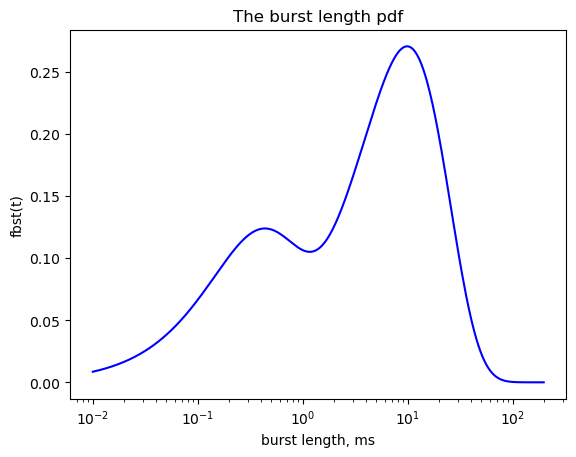

In [7]:
t, fbst = burst.calculate_burst_length_pdf()
plt.semilogx(t*1000, fbst, 'b-')
plt.ylabel('fbst(t)')
plt.xlabel('burst length, ms')
plt.title('The burst length pdf')

Display the conditional burst length distribution:

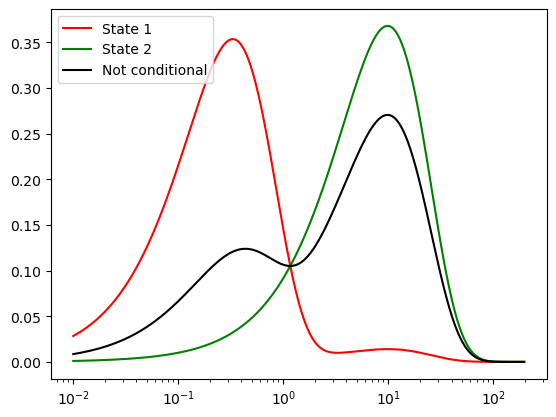

In [8]:
t, fbst, cfbst = burst.calculate_burst_length_pdf(conditional=True)
plots = []
for i in range(mec.kA):
    handle, = plt.semilogx(t*1000, cfbst[i], my_colour[i]+'-', label="State {0:d}".format(i+1))
    plots.append(handle)
handle, = plt.semilogx(t*1000, fbst, 'k-', label="Not conditional")
plots.append(handle)
plt.legend(handles=plots);

In [9]:
print(burst.print_openings_pdf)



PDF of total open time per burst
|   Term |   Amplitude |   Rate (1/sec) |   tau (ms) |   Area (%) |
|--------+-------------+----------------+------------+------------|
|      1 |     76.3456 |        103.855 |   9.62885  |    73.5121 |
|      2 |    802.093  |       3028.15  |   0.330235 |    26.4879 |
Mean (ms) = 7.1658		SD = 9.2207		SD/mean = 1.2868


PDF of first opening in a burst with 2 or more openings
|   Term |   Amplitude |   Rate (1/sec) |   tau (ms) |   Area (%) |
|--------+-------------+----------------+------------+------------|
|      1 |    495.125  |        500.654 |   1.99739  |    98.8957 |
|      2 |     33.6814 |       3050.01  |   0.327867 |     1.1043 |
Mean (ms) = 1.979		SD = 1.9943		SD/mean = 1.0077


Geometric PDF of number (r) of openings per burst (unconditional)
|   Term |        w |        rho |   area(%) |   Norm mean |
|--------+----------+------------+-----------+-------------|
|      1 | 0.260915 | 0.00714405 |   26.2793 |     1.0072  |
|      2 | 0.

Display the distribution of number of openings per burst:

(0.0, 11.0)

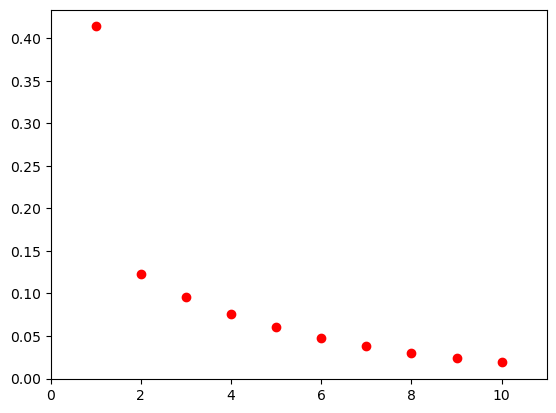

In [10]:
n = 10
r, Pr = burst.calculate_burst_openings_pdf(n)
plt.plot(r, Pr,'ro')
plt.xlim([0, 11])

Display the conditional distribution of number of openings per burst:

(0.0, 11.0)

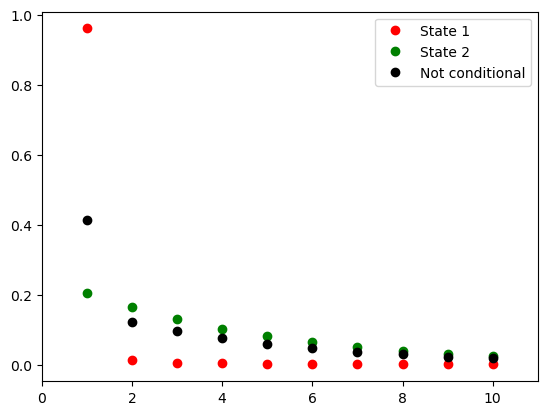

In [11]:
n = 10
r, Pr, cPr = burst.calculate_burst_openings_pdf(n, conditional=True)
plots = []
for i in range(len(cPr)):
    handle, = plt.plot(r, cPr[i], my_colour[i]+'o', label="State {0:d}".format(i+1))
    plots.append(handle)
handle, = plt.plot(r, Pr,'ko', label="Not conditional")
plots.append(handle)
plt.legend(handles=plots)
plt.xlim([0, n+1])

In [12]:
print(burst.print_shuttings_pdf)



PDF of gaps inside burst
|   Term |   Amplitude |   Rate (1/sec) |   tau (ms) |   Area (%) |
|--------+-------------+----------------+------------+------------|
|      1 |     23.4752 |         2053.2 |  0.487045  |    1.14335 |
|      2 |  18794.4    |        19011.8 |  0.0525989 |   98.8567  |
Mean (ms) = 0.057566		SD = 0.087066		SD/mean = 1.5125


PDF of gaps between bursts
|   Term |     Amplitude |   Rate (1/sec) |     tau (ms) |   Area (%) |
|--------+---------------+----------------+--------------+------------|
|      1 |    -66.168    |    2053.2      |    0.487045  |   -3.22268 |
|      2 | -52974.8      |   19011.8      |    0.0525989 | -278.641   |
|      3 |      0.263968 |       0.263895 | 3789.38      |  100.028   |
|      4 |     65.9122   |    2062.93     |    0.484747  |    3.19507 |
|      5 |  52974.7      |   19011.8      |    0.0525989 |  278.641   |
Mean (ms) = 3790.4		SD = 3789.4		SD/mean = 0.99972


PDF of total shut time per burst for bursts with at least 2 o

In [13]:
print(burst.print_popen)



Popen WITHIN BURST = (open time/burst)/(burst length) = 0.97786
Total Popen = (open time/burst)/(burst length + mean gap between bursts) = 0.0018869


  Display mean burst length versus concentration plot:

Solid line: mean burst length versus concentration.    X-axis: microMols; Y-axis: ms.


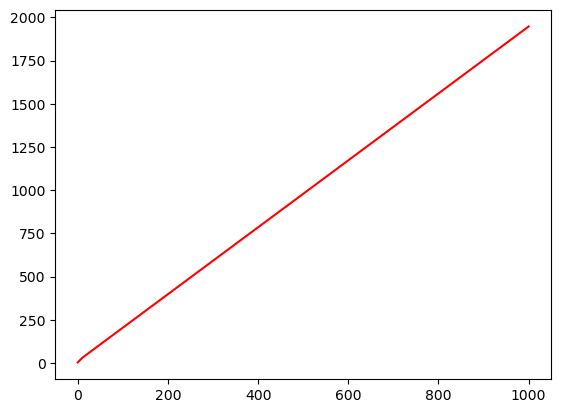

In [14]:
cmin = 10e-9
cmax = 1e-3
c, br, brblk = burst.burst_length_versus_conc_plot(mec, cmin, cmax)
plt.plot(c*1e6, br*1000,'r-')
print('Solid line: mean burst length versus concentration.' + '    X-axis: microMols; Y-axis: ms.')